In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Times New Roman'

In [2]:
import requests

series_categories_url = "https://api.stlouisfed.org/fred/series/categories"
category_url= "https://api.stlouisfed.org/fred/category"
api_key = "8b509196bae61e80ad63ffd48c91ae75"


In [3]:
reporting_directory_path = "../app/analytical-backend/data/08_reporting/"
simulation_output_directory = "simulation_output"

In [4]:
shap_impacts = pd.DataFrame()
cols = ['Series ID', 'Impact', 'TargetReferenceDate']

for fname in os.listdir(os.path.join(reporting_directory_path, simulation_output_directory)):
    if not fname.endswith("xlsx"): continue
    fpath = os.path.join(reporting_directory_path, simulation_output_directory, fname)

    ts = pd.read_excel(fpath, sheet_name="Nowcast Browser – Base")
    local_explanation = pd.read_excel(fpath, sheet_name="Local Explanation")
    
    row = ts.loc[ts["Actual"].isna()]
    local_explanation["TargetReferenceDate"] = row["Reference Date"].item()
    shap_impacts = pd.concat([shap_impacts, local_explanation[cols]])

In [5]:
import time

def make_request(url, params, max_retries=5, backoff_factor=3):
    retries = 0
    while retries < max_retries:
        response = requests.get(url, params=params)
        if response.status_code == 429:  # Too Many Requests
            retries += 1
            wait_time = backoff_factor ** retries  # Exponential backoff
            print(f"Rate limit exceeded. Retrying in {wait_time} seconds...")
            time.sleep(wait_time)  # Wait before retrying
        else:
            return response  # Return the response if not a rate limit error
    raise Exception(f"Exceeded max retries for {url} with params {params}")



In [6]:
responses = []

for series_id in tqdm(shap_impacts["Series ID"].unique()):
    dict_i = {"series_id": series_id}
    categories_response = make_request(series_categories_url, params={
        "series_id": series_id,
        "api_key": api_key,
        "file_type": "json"
    })
    categories_data = categories_response.json().get("categories", [])

    for category in categories_data:

        response = make_request(category_url, params={
            "category_id": category["id"],
            "api_key": api_key,
            "file_type": "json"
        })

        data = response.json().get("categories", [])

        parent_id = category["parent_id"]

        # Traverse up the category hierarchy
        while parent_id:
            # Get the parent category
            response = make_request(category_url, params={
                "category_id": parent_id,
                "api_key": api_key,
                "file_type": "json"
            })
            parent_data = response.json().get("categories", [])

            assert len(parent_data) == 1

            parent_category = parent_data[0]  # Assuming only one category is returned

            if parent_category["id"] != 0:
                parent_id = parent_category.get("parent_id")
                # Add the parent category to the dictionary
                dict_i["category_hierarchy"] = dict_i.get("category_hierarchy", [])
                dict_i["category_hierarchy"].insert(0, parent_category)  # Insert at the start
            else:
                break  # Exit the loop if no parent data is found

        # Append the full category hierarchy to responses
        dict_i["category_hierarchy"] = dict_i.get("category_hierarchy", [])
        dict_i["category_hierarchy"].append(category)  # Add the original category at the end
        responses.append(dict_i)


 31%|███       | 46/149 [01:05<02:18,  1.35s/it]

Rate limit exceeded. Retrying in 3 seconds...
Rate limit exceeded. Retrying in 9 seconds...
Rate limit exceeded. Retrying in 27 seconds...


 48%|████▊     | 72/149 [02:19<01:21,  1.06s/it]

Rate limit exceeded. Retrying in 3 seconds...
Rate limit exceeded. Retrying in 9 seconds...


 64%|██████▍   | 96/149 [03:06<01:34,  1.79s/it]

...

 81%|████████  | 120/149 [04:20<00:31,  1.09s/it]

Rate limit exceeded. Retrying in 3 seconds...
Rate limit exceeded. Retrying in 9 seconds...


 97%|█████████▋| 145/149 [05:09<00:07,  1.89s/it]

Rate limit exceeded. Retrying in 3 seconds...
Rate limit exceeded. Retrying in 9 seconds...
Rate limit exceeded. Retrying in 27 seconds...


100%|██████████| 149/149 [05:55<00:00,  2.39s/it]


In [7]:
# Sanity check
make_request(category_url, params={
                "category_id": 0,
                "api_key": api_key,
                "file_type": "json"
            }).json().get("categories")

[{'id': 0, 'name': 'Categories', 'parent_id': 0}]

In [8]:
main_categories = [
    "Money, Banking, & Finance",
    "Population, Employment, & Labor Markets",
    "National Accounts",
    "Production & Business Activity",
    "Prices",
    "International Data",
    "U.S. Regional Data",
    "Academic Data",
    "Housing",
    "Manufacturing",
    "Construction",
    "Retail Trade",
]

series_categories = []

for series_hierarchy in responses:
    categories = [c["name"] for c in series_hierarchy["category_hierarchy"]]
    intersection = set(categories).intersection(set(main_categories))
    assert len(intersection) > 0

    for category_name in intersection:
        series_categories.append({"series_id": series_hierarchy["series_id"], "category": category_name})

sc_df = pd.DataFrame(series_categories)
sc_df["category"] = sc_df["category"].replace({
    "International Data": "Others",
    "U.S. Regional Data": "Others",
    "Academic Data": "Others",
    "Housing": "Housing and construction",
    "Construction": "Housing and construction"
})
sc_df = sc_df.drop_duplicates()

prioritized_categories = sc_df.loc[~sc_df["category"].isin(["Production & Business Activity", "Others"])]

tmp = pd.concat([
    prioritized_categories,
    sc_df.loc[(sc_df["category"] == "Production & Business Activity") & ~sc_df["series_id"].isin(prioritized_categories["series_id"])]
])
series_categories_df = pd.concat([
    tmp,
    sc_df.loc[(sc_df["category"] == "Others") & ~sc_df["series_id"].isin(tmp["series_id"])]
]).drop_duplicates()

assert prioritized_categories.duplicated(subset=["series_id"]).sum() == 0
assert tmp.duplicated(subset=["series_id"]).sum() == 0
assert series_categories_df.duplicated(subset=["series_id"]).sum() == 0

assert series_categories_df.shape[0] == len(shap_impacts["Series ID"].unique())

In [9]:
categories_impacts = pd.merge(shap_impacts, series_categories_df, left_on="Series ID", right_on="series_id", how="left")

df = categories_impacts.copy()

In [6]:
categories = [
    ("Housing and construction", "#B84545"),
    ("Retail Trade", "#D1873D"),
    ("Production & Business Activity", "#35457E"),
    ("Manufacturing", "#56874C"),
    ("Money, Banking, & Finance", "#0D96D4"),
    ("Prices", "#CB9285"),
    ("Population, Employment, & Labor Markets", "#8FA985"),
    ("National Accounts", "#B689CF"),
    ("Others", "#CDCDD1"),
]
category_colors = dict(categories)

df_plt = pd.read_csv(os.path.join(reporting_directory_path, "illustrative_example.csv"), index_col=0)
df_plt.index = pd.to_datetime(df_plt.index)

In [11]:
legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in category_colors.items()
]

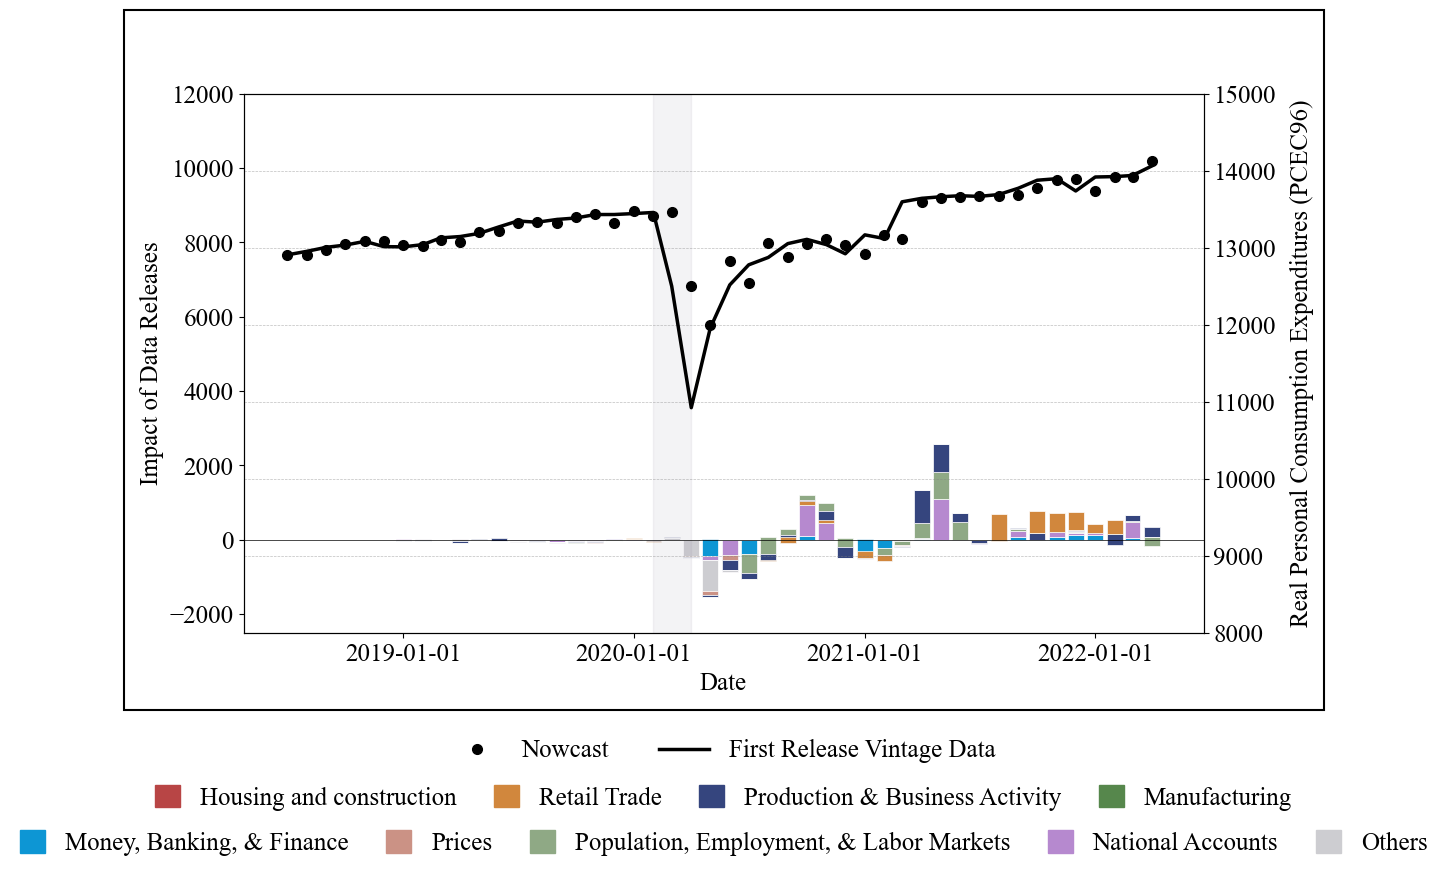

In [12]:
# Pivot the data for plotting
pivot_df = df.pivot_table(
    index='TargetReferenceDate',
    columns='category',
    values='Impact',
    aggfunc='sum',
).fillna(0).sort_index().loc["2019-01-01":]

fig, ax = plt.subplots(1, 1, figsize=(12, 7))

dates = pivot_df.index
bottom = np.zeros(len(dates))

for col in pivot_df.columns:
    color = category_colors.get(col)
    ax.bar(dates, pivot_df[col], bottom=bottom, label=col, color=color, width=25, edgecolor='white', linewidth=0.5)
    bottom += pivot_df[col].values

ax.fill_between(
        x=pivot_df.loc["2020-02-01":"2020-04-01"].index, 
        y1=-3000, 
        y2=12000,
        color="#938BA1",
        alpha=0.1)

# Axis labels and formatting
ax.set_ylabel("Impact of Data Releases", fontsize=18)
ax.set_xlabel("Date", fontsize=18)

ax.set_xticks(pivot_df.index[::12])
ax.set_xticklabels(pivot_df.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

ax.set_ylim([-2500, 12000])
ax.tick_params(axis='y', labelsize=18)

ax2 = ax.twinx()
ax2.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='D', markersize=0, linewidth=2.5)
ax2.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=7, linewidth=0)
ax2.set_ylim([8000, 15000])
ax2.set_ylabel('Real Personal Consumption Expenditures (PCEC96)', fontsize=18, labelpad=10)
ax2.tick_params(axis='y', labelsize=18)

# First row: 4 items
fig.legend(
    handles=legend_patches[:4],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.075),
    ncol=5,
    frameon=False,
    fontsize=18,
    handlelength=1,
    handleheight=1,
    columnspacing=1.5
)

# Second row: 5 items
fig.legend(
    handles=legend_patches[4:],
    loc='upper center',
    bbox_to_anchor=(0.5, -0.14),
    ncol=7,
    frameon=False,
    fontsize=18,
    handlelength=1,
    handleheight=1,
    columnspacing=1.5,
)

handles2, labels2 = ax2.get_legend_handles_labels()
# Ensure desired order
desired_order = [
    "Nowcast",
    "First Release Vintage Data",
]
order = [labels2.index(label) for label in desired_order if label in labels2]

fig.legend(
    [handles2[i] for i in order], [labels2[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.01),
    ncol=3,
    frameon=False
)

ax.axhline(y=0, color='black', linewidth=0.5)
plt.grid(axis='y', linestyle='--', color='gray', linewidth=0.5, alpha=0.5)

# Add outer frame (border)
frame = mpatches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.subplots_adjust(top=0.88, left=0.1, right=0.9)
plt.show()
